In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import dgl
import random
from scipy.sparse import csr_matrix
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics.cluster import normalized_mutual_info_score
import os

In [6]:
import so as so

In [7]:
seed = 42
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
dgl.random.seed(seed)

In [8]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [9]:
files = os.listdir('./soDGVAE_dataset/dataset/2_large_wang_zeng/')
files

['mouse_BrainAtals_well11_WangXiao.h5ad',
 'mouse_brain_C57BL6J-2.061_zhuang.h5ad',
 'mouse_BrainAtals_sagittal1_WangXiao.h5ad',
 'mouse_brainC57BL6J-638850.37_zeng.h5ad']

In [65]:
files = [
    'mouse_BrainAtals_well11_WangXiao.h5ad',
 'mouse_brain_C57BL6J-2.061_zhuang.h5ad',
 'mouse_BrainAtals_sagittal1_WangXiao.h5ad',
 'mouse_brainC57BL6J-638850.37_zeng.h5ad',
]

In [66]:
data_list = [sc.read_h5ad(f'./soDGVAE_dataset/dataset/3_large_wang_zeng/{file}') for file in files]
data_list

[AnnData object with n_obs × n_vars = 43341 × 1022
     obs: 'Main_molecular_cell_type', 'Sub_molecular_cell_type', 'Main_molecular_tissue_region', 'Sub_molecular_tissue_region', 'Molecular_spatial_cell_type', 'subregion'
     uns: 'Main_molecular_tissue_region_colors'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 28240 × 1120
     obs: 'brain_section_label', 'major_brain_region', 'ccf_region_name', 'cell_type', 'subclass_transfer', 'subregion'
     var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ENS'
     uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
     obsm: 'X_CCF', 'X_spatial_coords', 'X_umap', 'spatial',
 AnnData object with n_obs × n_vars = 91246 × 1022
     obs: 'Main_molecular_cell_type', 'Sub_molecular_cell_type', 'Main_molecular_tissue_region', 'Sub_molecular_tissue_region', 'Molecular_spatial_cell_type', 'subregion'
   

In [67]:
batch_names = files
batch_names

['mouse_BrainAtals_well11_WangXiao.h5ad',
 'mouse_brain_C57BL6J-2.061_zhuang.h5ad',
 'mouse_BrainAtals_sagittal1_WangXiao.h5ad',
 'mouse_brainC57BL6J-638850.37_zeng.h5ad']

In [68]:
import numpy as np
np.set_printoptions(suppress=True)

In [69]:
batch_key = 'batch'
adata = so.pp.process_adata(data_list, label=batch_key, keys=batch_names, n_top_features=None, target_sum=1e4)
adata

AnnData object with n_obs × n_vars = 252972 × 258
    obs: 'subregion', 'original_index', 'spot_quality', 'batch'
    uns: 'log1p', 'mu_bg', 'std_bg'
    obsm: 'spatial'
    layers: 'counts', 'norm_log'

In [70]:
adata.X.max(), adata.X.min()

(9.210440366976515, 0.0)

In [79]:
rad_cutoff_list = [300, 70, 300, 0.07]
adata, g = so.pp.process_graph(adata, data_list, cutoff_list=rad_cutoff_list)

cal spatial net in data_list
------Calculating spatial graph...
The graph contains 863482 edges, 43341 cells.
19.9230 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 954602 edges, 28240 cells.
33.8032 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 2988398 edges, 91246 cells.
32.7510 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 2944689 edges, 90145 cells.
32.6661 neighbors per cell on average.


In [80]:
path_results = f'./log/integration_radius_256_4datasets/'

In [81]:
adata

AnnData object with n_obs × n_vars = 252972 × 258
    obs: 'subregion', 'original_index', 'spot_quality', 'batch'
    uns: 'log1p', 'mu_bg', 'std_bg', 'adj'
    obsm: 'spatial', 'X_soGCL'
    layers: 'counts', 'norm_log'

In [43]:
adata_int = so.model.DGVAE(adata=adata,
                            n_epoch=2,
                            batch_size=1024,
                            verbose=False,
                            gpu=0,
                            random_seed=42,
                            output_dir=path_results,
                            num_heads=2,
                            h_dim=16,
                            reconstruct_loss='orig',
                            graph_loss=False,
                            )

clip
reconstruct_loss == orig


Epochs: 100%|█| 2/2 [00:25<00:00, 12.66s/it, recon_loss=527.0428, kl_loss=5.0896, mmd2=0.0000, graph_loss=0.0000, lr: 0.
Infer latent: 100%|███████████████████████████████████████████████████████████████████| 248/248 [00:04<00:00, 61.81it/s]


In [44]:
adata_int

AnnData object with n_obs × n_vars = 252972 × 258
    obs: 'subregion', 'original_index', 'spot_quality', 'batch'
    uns: 'log1p', 'mu_bg', 'std_bg', 'epoch_loss_df', 'adj'
    obsm: 'spatial', 'X_soDGVAE'
    layers: 'counts', 'norm_log'

In [84]:
del adata_int.uns['adj']

In [85]:
adata_int.write_h5ad(f'{path_results}adata_int.h5ad', compression='gzip')

In [1]:
import scanpy as sc
import cupy as cp
import time
import rapids_singlecell as rsc
import warnings
warnings.filterwarnings("ignore")

/home/gzh/anaconda3/envs/rapids_singlecell/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
rmm.reinitialize(
    managed_memory=False,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [3]:
import numpy as np
import scanpy as sc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.neighbors import NearestNeighbors

def compute_ARI(adata, anno_key, pred_key):
    return adjusted_rand_score(adata.obs[anno_key], adata.obs[pred_key])

def compute_NMI(adata, anno_key, pred_key):
    return normalized_mutual_info_score(adata.obs[anno_key], adata.obs[pred_key])

In [4]:
sc.set_figure_params(dpi=150, figsize=(2, 2), frameon=False)    # TODO 是否画边框

In [5]:
def kmeans_cluster(adata, n_clusters=10, used_embedding='X_pca', mode='KMeans', key_add='kmeans'):
    from sklearn.cluster import KMeans, MiniBatchKMeans
    if mode == 'KMeans':
        model = KMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(adata.obsm[used_embedding])
    elif mode == 'MiniBatchKMeans':
        model = MiniBatchKMeans(n_clusters=n_clusters, random_state=0, init='k-means++').fit(
            adata.obsm[used_embedding])
    else:
        print('mode in [KMeans, MiniBatchKMeans]')
        raise NotImplementedError
    cell_label = model.labels_
    adata.obs.loc[:, key_add] = cell_label
    adata.obs.loc[:, key_add] = adata.obs.loc[:, key_add].astype(str)
    return adata

In [6]:
path_results = f'./log/integration_radius_256_4datasets/'

In [7]:
adata_int = sc.read_h5ad(f'{path_results}adata_int.h5ad')
adata_int

AnnData object with n_obs × n_vars = 252972 × 258
    obs: 'subregion', 'original_index', 'spot_quality', 'batch'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg'
    obsm: 'X_soDGVAE', 'spatial'
    layers: 'counts', 'norm_log'

In [10]:
adata_int.obs.loc[:, 'subregion'] = adata_concat.obs.loc[:, 'subregion'].to_numpy()

In [11]:
adata_int.obs.loc[:, 'region'] = adata_int.obs.loc[:, 'subregion']
adata_int.obs.loc[:, 'region'].unique()

array(['HPF', 'CTX', 'STR', 'OLF', 'FiberTracts', 'Medulla',
       'Mixed_LSX_HY_MB_HB', 'TH', 'Unassigned', 'VS', 'Pons', 'CB', 'HY',
       'MB', 'PAL'], dtype=object)

In [12]:
%%time
rsc.pp.neighbors(adata_int, use_rep='X_soDGVAE')
rsc.tl.umap(adata_int)

CPU times: user 983 ms, sys: 336 ms, total: 1.32 s
Wall time: 1.61 s


In [10]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=15, key_add='sub_kmeans')

CPU times: user 4.46 s, sys: 440 ms, total: 4.9 s
Wall time: 332 ms


AnnData object with n_obs × n_vars = 252972 × 258
    obs: 'subregion', 'original_index', 'spot_quality', 'batch', 'region', 'sub_kmeans'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

In [11]:
%%time
kmeans_cluster(adata_int, mode='KMeans', used_embedding='X_soDGVAE', n_clusters=15, key_add='kmeans')

CPU times: user 4.08 s, sys: 186 ms, total: 4.27 s
Wall time: 259 ms


AnnData object with n_obs × n_vars = 252972 × 258
    obs: 'subregion', 'original_index', 'spot_quality', 'batch', 'region', 'sub_kmeans', 'kmeans'
    uns: 'epoch_loss_df', 'log1p', 'mu_bg', 'std_bg', 'neighbors', 'umap'
    obsm: 'X_soDGVAE', 'spatial', 'X_umap'
    layers: 'counts', 'norm_log'
    obsp: 'distances', 'connectivities'

In [17]:
batch_names = adata_int.obs.loc[:, 'batch'].unique()

mouse_BrainAtals_well11_WangXiao.h5ad


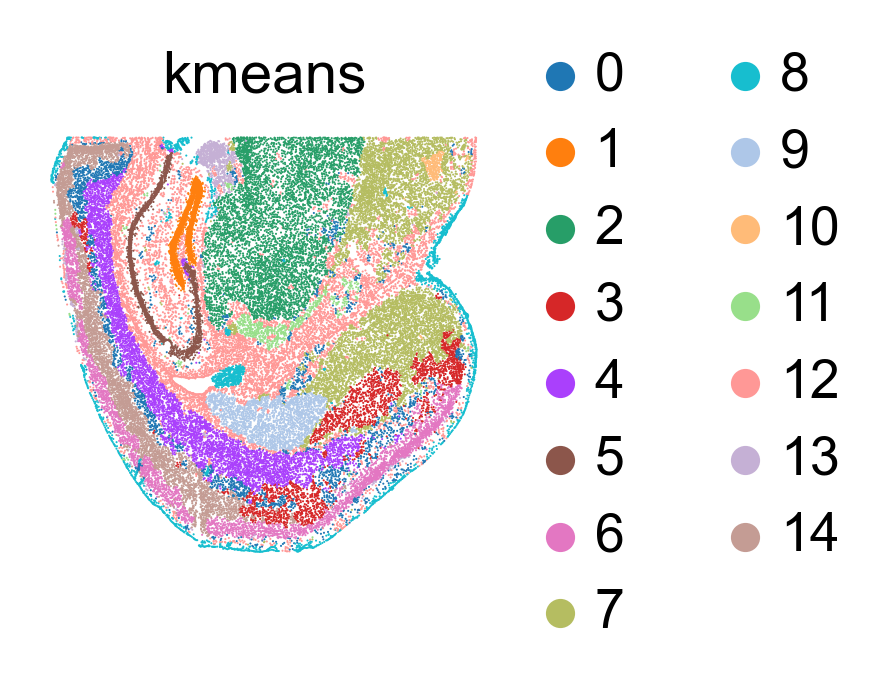

mouse_BrainAtals_sagittal1_WangXiao.h5ad


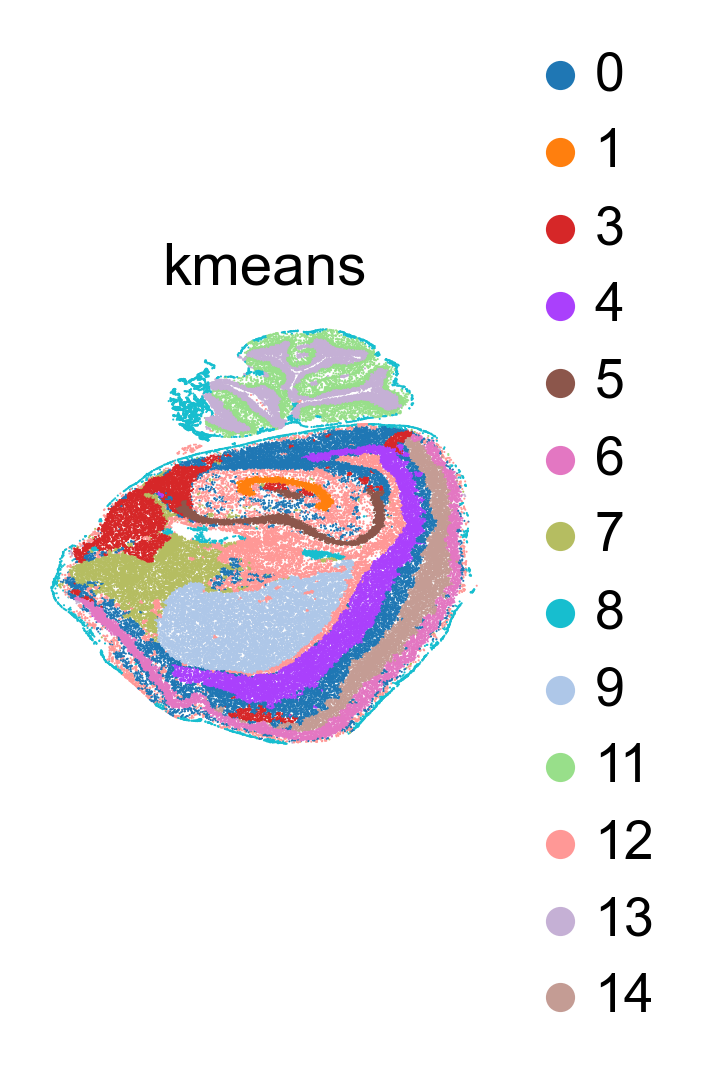

mouse_brain_C57BL6J-2.061_zhuang.h5ad


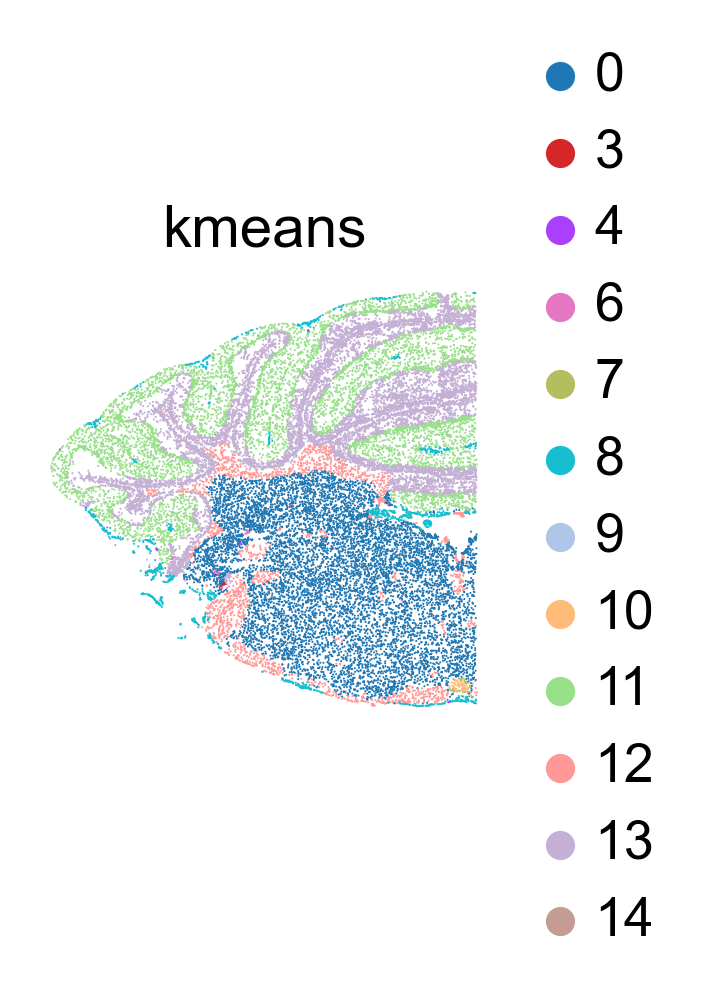

mouse_brainC57BL6J-638850.37_zeng.h5ad


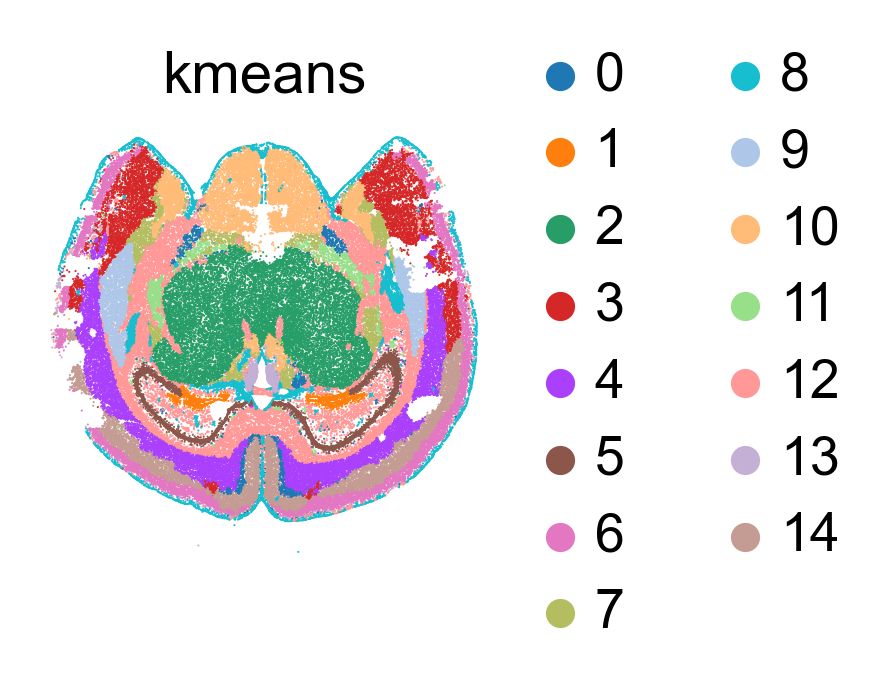

In [14]:
for batch in batch_names:
    temp = adata_int[adata_int.obs.loc[:, 'batch'] == batch, :]
    print(batch)
    sc.pl.embedding(temp, color=['kmeans'], ncols=5, basis='spatial', size=1, wspace=1)